Number of cities: 100
Distance matrix shape: (100, 100)
Adjacency shape: (100, 100)
Normalized adjacency shape: (100, 100)
Node feature shape: (100, 3)
Start city: 0 | pseudo route distance: 8.466965
Start city: 1 | pseudo route distance: 7.880031
Start city: 2 | pseudo route distance: 8.030834
Start city: 3 | pseudo route distance: 8.162343
Start city: 4 | pseudo route distance: 7.9357576
Start city: 5 | pseudo route distance: 8.250826
Start city: 6 | pseudo route distance: 7.9867287
Start city: 7 | pseudo route distance: 8.37647
Start city: 8 | pseudo route distance: 8.047838
Start city: 9 | pseudo route distance: 7.9274263
Start city: 10 | pseudo route distance: 8.216549
Start city: 11 | pseudo route distance: 8.084217
Start city: 12 | pseudo route distance: 8.034227
Start city: 13 | pseudo route distance: 9.044995
Start city: 14 | pseudo route distance: 8.309969
Start city: 15 | pseudo route distance: 8.396156
Start city: 16 | pseudo route distance: 8.009449
Start city: 17 | pseudo

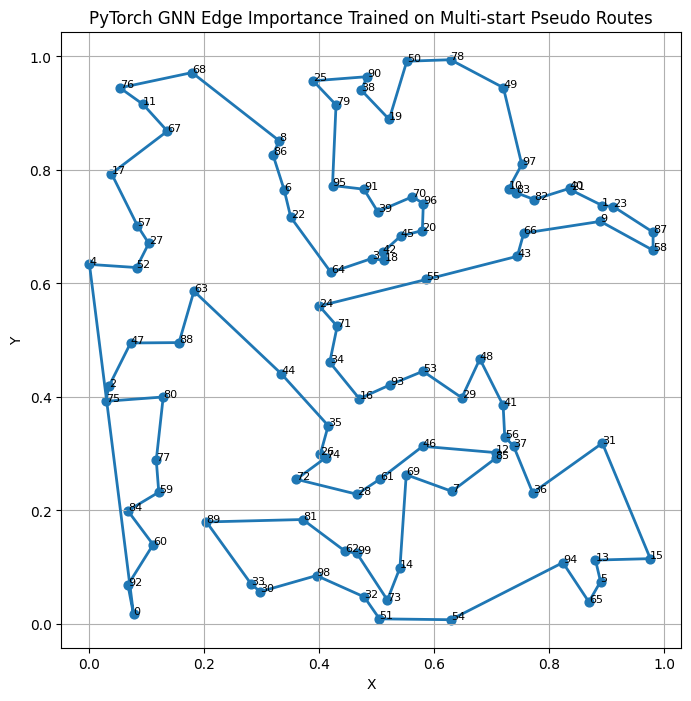

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

df = pd.read_csv("large.csv", header=None)

coords = df.values.astype(np.float32)

N_SAMPLE = 100
coords = coords[:N_SAMPLE]

num_nodes = len(coords)

print("Number of cities:", num_nodes)

def compute_distance_matrix(coords):
    diff = coords[:, None, :] - coords[None, :, :]
    D = np.sqrt(np.sum(diff ** 2, axis=-1))
    return D

distance_matrix = compute_distance_matrix(coords)

print("Distance matrix shape:", distance_matrix.shape)

K = 10

A = np.zeros((num_nodes, num_nodes), dtype=np.float32)

for i in range(num_nodes):

    nearest = np.argsort(distance_matrix[i])[1:K + 1]

    for j in nearest:

        A[i][j] = 1
        A[j][i] = 1

A = A + np.eye(num_nodes, dtype=np.float32)

print("Adjacency shape:", A.shape)

degree = np.sum(A, axis=1)

D_inv_sqrt = np.diag(
    1.0 / np.sqrt(degree + 1e-8)
)

A_hat = D_inv_sqrt @ A @ D_inv_sqrt

print("Normalized adjacency shape:", A_hat.shape)

avg_distance = np.mean(
    distance_matrix,
    axis=1
).reshape(-1, 1)

X = np.hstack([
    coords,
    avg_distance
]).astype(np.float32)

X = (
    X - X.mean(axis=0)
) / (
    X.std(axis=0) + 1e-8
)

num_features = X.shape[1]

print("Node feature shape:", X.shape)

def nearest_neighbor_route(D, start=0):

    n = len(D)

    visited = set([start])

    route = [start]

    current = start

    while len(route) < n:

        best_node = None
        best_dist = float("inf")

        for j in range(n):

            if j not in visited:

                if D[current][j] < best_dist:

                    best_dist = D[current][j]
                    best_node = j

        route.append(best_node)

        visited.add(best_node)

        current = best_node

    route.append(start)

    return route

def route_distance(route, D):

    total = 0

    for i in range(len(route) - 1):

        total += D[route[i]][route[i + 1]]

    return total

def two_opt(route, D, max_iter=50):

    best = route[:]

    best_distance = route_distance(best, D)

    improved = True

    iteration = 0

    while improved and iteration < max_iter:

        improved = False

        iteration += 1

        for i in range(1, len(best) - 2):

            for j in range(i + 1, len(best) - 1):

                if j - i == 1:
                    continue

                new_route = best[:]

                new_route[i:j] = reversed(new_route[i:j])

                new_distance = route_distance(new_route, D)

                if new_distance < best_distance:

                    best = new_route

                    best_distance = new_distance

                    improved = True

    return best

NUM_STARTS = min(num_nodes, 30)

start_cities = list(range(NUM_STARTS))

pseudo_routes = []

pseudo_distances = []

for start in start_cities:

    initial_route = nearest_neighbor_route(
        distance_matrix,
        start=start
    )

    pseudo_route = two_opt(
        initial_route,
        distance_matrix,
        max_iter=20
    )

    pseudo_routes.append(pseudo_route)

    dist = route_distance(
        pseudo_route,
        distance_matrix
    )

    pseudo_distances.append(dist)

    print(
        "Start city:",
        start,
        "| pseudo route distance:",
        dist
    )

print("\nTotal pseudo routes generated:", len(pseudo_routes))

best_route_index = np.argmin(pseudo_distances)

best_pseudo_route = pseudo_routes[best_route_index]

best_pseudo_distance = pseudo_distances[best_route_index]

print("\nBest pseudo route start city:", start_cities[best_route_index])
print("Best pseudo route distance:", best_pseudo_distance)

all_edge_labels = []

for pseudo_route in pseudo_routes:

    edge_labels = np.zeros(
        (num_nodes, num_nodes),
        dtype=np.float32
    )

    for i in range(len(pseudo_route) - 1):

        u = pseudo_route[i]
        v = pseudo_route[i + 1]

        edge_labels[u][v] = 1
        edge_labels[v][u] = 1

    all_edge_labels.append(edge_labels)

all_edge_labels = np.array(
    all_edge_labels,
    dtype=np.float32
)

print("\nAll edge labels shape:", all_edge_labels.shape)

Y_soft = np.mean(
    all_edge_labels,
    axis=0
).astype(np.float32)

np.fill_diagonal(Y_soft, 0)

print("Soft edge-label matrix shape:", Y_soft.shape)
print("Soft labels min:", Y_soft.min())
print("Soft labels max:", Y_soft.max())

X_torch = torch.tensor(
    X,
    dtype=torch.float32
)

A_hat_torch = torch.tensor(
    A_hat,
    dtype=torch.float32
)

Y_torch = torch.tensor(
    Y_soft,
    dtype=torch.float32
)

class GNN_EdgeImportance(nn.Module):

    def __init__(self, input_dim, hidden_dim, embedding_dim):

        super().__init__()

        self.fc1 = nn.Linear(
            input_dim,
            hidden_dim
        )

        self.fc2 = nn.Linear(
            hidden_dim,
            embedding_dim
        )

    def forward(self, X, A_hat):

        H = torch.matmul(
            A_hat,
            X
        )

        H = self.fc1(H)

        H = torch.relu(H)

        H = torch.matmul(
            A_hat,
            H
        )

        H = self.fc2(H)

        H = torch.relu(H)

        scores = torch.matmul(
            H,
            H.T
        )

        edge_importance = torch.sigmoid(scores)

        return edge_importance, H

model = GNN_EdgeImportance(
    input_dim=num_features,
    hidden_dim=64,
    embedding_dim=32
)

criterion = nn.BCELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 300

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    pred_edges, embeddings = model(
        X_torch,
        A_hat_torch
    )

    loss = criterion(
        pred_edges,
        Y_torch
    )

    loss.backward()

    optimizer.step()

    if epoch % 50 == 0:

        print(
            "Epoch:",
            epoch,
            "Loss:",
            loss.item()
        )

model.eval()

with torch.no_grad():

    edge_importance_torch, embeddings = model(
        X_torch,
        A_hat_torch
    )

edge_importance = edge_importance_torch.numpy()

np.fill_diagonal(edge_importance, 0)

print("\nEdge importance shape:", edge_importance.shape)

distance_norm = distance_matrix / (
    distance_matrix.max() + 1e-8
)

epsilon = 1e-6

learned_cost = distance_matrix / (edge_importance + epsilon)

np.fill_diagonal(learned_cost, 1e9)

print("Learned cost shape:", learned_cost.shape)

def beam_search_route(cost_matrix, start=0, beam_width=5):

    n = len(cost_matrix)

    beams = [
        ([start], 0.0, set([start]))
    ]

    while True:

        new_beams = []

        for route, cost, visited in beams:

            if len(route) == n:

                final_cost = cost + cost_matrix[route[-1]][start]

                final_route = route + [start]

                new_beams.append(
                    (final_route, final_cost, visited)
                )

                continue

            current = route[-1]

            for nxt in range(n):

                if nxt not in visited:

                    new_route = route + [nxt]

                    new_cost = cost + cost_matrix[current][nxt]

                    new_visited = set(visited)

                    new_visited.add(nxt)

                    new_beams.append(
                        (new_route, new_cost, new_visited)
                    )

        new_beams = sorted(
            new_beams,
            key=lambda x: x[1]
        )

        beams = new_beams[:beam_width]

        if len(beams[0][0]) == n + 1:

            break

    return beams[0][0]

start_city = 0

gnn_route = beam_search_route(
    learned_cost,
    start=start_city,
    beam_width=5
)

print("\nGNN beam-search route distance before final 2-opt:")
print(
    route_distance(
        gnn_route,
        distance_matrix
    )
)

final_route = two_opt(
    gnn_route,
    distance_matrix,
    max_iter=20
)

final_distance = route_distance(
    final_route,
    distance_matrix
)

print("\nFinal Route:")
print(final_route)

print("\nFinal Route Distance:")
print(final_distance)

print("\n================ COMPARISON ================")

selected_start_index = start_cities.index(start_city)

same_start_pseudo_route = pseudo_routes[selected_start_index]

same_start_pseudo_distance = pseudo_distances[selected_start_index]

print("Selected start city:")
print(start_city)

print("\nPseudo route distance for this start city:")
print(same_start_pseudo_distance)

print("\nGNN + Beam Search + 2-opt final distance:")
print(final_distance)

if final_distance < same_start_pseudo_distance:

    improvement = (
        (same_start_pseudo_distance - final_distance)
        / same_start_pseudo_distance
    ) * 100

    print("\nGNN final route is better than pseudo route of same start city.")
    print("Improvement (%):", improvement)

elif final_distance > same_start_pseudo_distance:

    worsening = (
        (final_distance - same_start_pseudo_distance)
        / same_start_pseudo_distance
    ) * 100

    print("\nPseudo route of same start city is better.")
    print("GNN final route is worse by (%):", worsening)

else:

    print("\nBoth routes have the same distance.")

route_coords = coords[final_route]

plt.figure(figsize=(8, 8))

plt.scatter(
    coords[:, 0],
    coords[:, 1],
    s=40
)

plt.plot(
    route_coords[:, 0],
    route_coords[:, 1],
    linewidth=2
)

for i in range(num_nodes):

    plt.text(
        coords[i, 0],
        coords[i, 1],
        str(i),
        fontsize=8
    )

plt.title(
    "PyTorch GNN Edge Importance Trained on Multi-start Pseudo Routes"
)

plt.xlabel("X")
plt.ylabel("Y")

plt.grid(True)

plt.show()

Number of cities: 100
Distance matrix shape: (100, 100)
Adjacency shape: (100, 100)
Normalized adjacency shape: (100, 100)
Node feature shape: (100, 3)
Start city: 0 | pseudo route distance: 8.466965
Start city: 1 | pseudo route distance: 7.880031
Start city: 2 | pseudo route distance: 8.030834
Start city: 3 | pseudo route distance: 8.162343
Start city: 4 | pseudo route distance: 7.9357576
Start city: 5 | pseudo route distance: 8.250826
Start city: 6 | pseudo route distance: 7.9867287
Start city: 7 | pseudo route distance: 8.37647
Start city: 8 | pseudo route distance: 8.047838
Start city: 9 | pseudo route distance: 7.9274263
Start city: 10 | pseudo route distance: 8.216549
Start city: 11 | pseudo route distance: 8.084217
Start city: 12 | pseudo route distance: 8.034227
Start city: 13 | pseudo route distance: 9.044995
Start city: 14 | pseudo route distance: 8.309969
Start city: 15 | pseudo route distance: 8.396156
Start city: 16 | pseudo route distance: 8.009449
Start city: 17 | pseudo

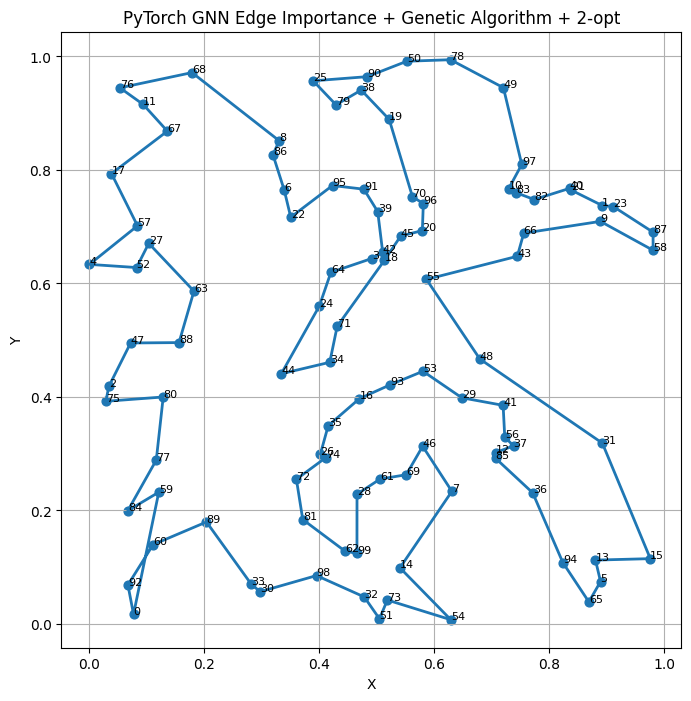

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


df = pd.read_csv("large.csv", header=None)

coords = df.values.astype(np.float32)

N_SAMPLE = 100
coords = coords[:N_SAMPLE]

num_nodes = len(coords)

print("Number of cities:", num_nodes)


def compute_distance_matrix(coords):
    diff = coords[:, None, :] - coords[None, :, :]
    D = np.sqrt(np.sum(diff ** 2, axis=-1))
    return D


distance_matrix = compute_distance_matrix(coords)

print("Distance matrix shape:", distance_matrix.shape)



K = 10

A = np.zeros((num_nodes, num_nodes), dtype=np.float32)

for i in range(num_nodes):

    nearest = np.argsort(distance_matrix[i])[1:K + 1]

    for j in nearest:

        A[i][j] = 1
        A[j][i] = 1


A = A + np.eye(num_nodes, dtype=np.float32)

print("Adjacency shape:", A.shape)



degree = np.sum(A, axis=1)

D_inv_sqrt = np.diag(
    1.0 / np.sqrt(degree + 1e-8)
)

A_hat = D_inv_sqrt @ A @ D_inv_sqrt

print("Normalized adjacency shape:", A_hat.shape)


avg_distance = np.mean(
    distance_matrix,
    axis=1
).reshape(-1, 1)

X = np.hstack([
    coords,
    avg_distance
]).astype(np.float32)


X = (
    X - X.mean(axis=0)
) / (
    X.std(axis=0) + 1e-8
)

num_features = X.shape[1]

print("Node feature shape:", X.shape)


def nearest_neighbor_route(D, start=0):

    n = len(D)

    visited = set([start])

    route = [start]

    current = start

    while len(route) < n:

        best_node = None
        best_dist = float("inf")

        for j in range(n):

            if j not in visited:

                if D[current][j] < best_dist:

                    best_dist = D[current][j]
                    best_node = j

        route.append(best_node)

        visited.add(best_node)

        current = best_node

    route.append(start)

    return route



def route_distance(route, D):

    total = 0

    for i in range(len(route) - 1):

        total += D[route[i]][route[i + 1]]

    return total



def two_opt(route, D, max_iter=50):

    best = route[:]

    best_distance = route_distance(best, D)

    improved = True

    iteration = 0

    while improved and iteration < max_iter:

        improved = False

        iteration += 1

        for i in range(1, len(best) - 2):

            for j in range(i + 1, len(best) - 1):

                if j - i == 1:
                    continue

                new_route = best[:]

                new_route[i:j] = reversed(new_route[i:j])

                new_distance = route_distance(new_route, D)

                if new_distance < best_distance:

                    best = new_route

                    best_distance = new_distance

                    improved = True

    return best



NUM_STARTS = min(num_nodes, 30)

start_cities = list(range(NUM_STARTS))

pseudo_routes = []

pseudo_distances = []

for start in start_cities:

    initial_route = nearest_neighbor_route(
        distance_matrix,
        start=start
    )

    pseudo_route = two_opt(
        initial_route,
        distance_matrix,
        max_iter=20
    )

    pseudo_routes.append(pseudo_route)

    dist = route_distance(
        pseudo_route,
        distance_matrix
    )

    pseudo_distances.append(dist)

    print(
        "Start city:",
        start,
        "| pseudo route distance:",
        dist
    )

print("\nTotal pseudo routes generated:", len(pseudo_routes))

best_route_index = np.argmin(pseudo_distances)

best_pseudo_route = pseudo_routes[best_route_index]

best_pseudo_distance = pseudo_distances[best_route_index]

print("\nBest pseudo route start city:", start_cities[best_route_index])
print("Best pseudo route distance:", best_pseudo_distance)



all_edge_labels = []

for pseudo_route in pseudo_routes:

    edge_labels = np.zeros(
        (num_nodes, num_nodes),
        dtype=np.float32
    )

    for i in range(len(pseudo_route) - 1):

        u = pseudo_route[i]
        v = pseudo_route[i + 1]

        edge_labels[u][v] = 1
        edge_labels[v][u] = 1

    all_edge_labels.append(edge_labels)

all_edge_labels = np.array(
    all_edge_labels,
    dtype=np.float32
)

print("\nAll edge labels shape:", all_edge_labels.shape)



Y_soft = np.mean(
    all_edge_labels,
    axis=0
).astype(np.float32)

np.fill_diagonal(Y_soft, 0)

print("Soft edge-label matrix shape:", Y_soft.shape)
print("Soft labels min:", Y_soft.min())
print("Soft labels max:", Y_soft.max())



X_torch = torch.tensor(
    X,
    dtype=torch.float32
)

A_hat_torch = torch.tensor(
    A_hat,
    dtype=torch.float32
)

Y_torch = torch.tensor(
    Y_soft,
    dtype=torch.float32
)



class GNN_EdgeImportance(nn.Module):

    def __init__(self, input_dim, hidden_dim, embedding_dim):

        super().__init__()

        self.fc1 = nn.Linear(
            input_dim,
            hidden_dim
        )

        self.fc2 = nn.Linear(
            hidden_dim,
            embedding_dim
        )

    def forward(self, X, A_hat):

        H = torch.matmul(
            A_hat,
            X
        )

        H = self.fc1(H)

        H = torch.relu(H)

        H = torch.matmul(
            A_hat,
            H
        )

        H = self.fc2(H)

        H = torch.relu(H)

        scores = torch.matmul(
            H,
            H.T
        )

        edge_importance = torch.sigmoid(scores)

        return edge_importance, H


model = GNN_EdgeImportance(
    input_dim=num_features,
    hidden_dim=64,
    embedding_dim=32
)

criterion = nn.BCELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


epochs = 300

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    pred_edges, embeddings = model(
        X_torch,
        A_hat_torch
    )

    loss = criterion(
        pred_edges,
        Y_torch
    )

    loss.backward()

    optimizer.step()

    if epoch % 50 == 0:

        print(
            "Epoch:",
            epoch,
            "Loss:",
            loss.item()
        )


model.eval()

with torch.no_grad():

    edge_importance_torch, embeddings = model(
        X_torch,
        A_hat_torch
    )

edge_importance = edge_importance_torch.numpy()

np.fill_diagonal(edge_importance, 0)

print("\nEdge importance shape:", edge_importance.shape)


distance_norm = distance_matrix / (
    distance_matrix.max() + 1e-8
)

epsilon = 1e-6

learned_cost = distance_matrix / (edge_importance + epsilon)

np.fill_diagonal(learned_cost, 1e9)

print("Learned cost shape:", learned_cost.shape)


def create_individual(num_nodes, start):

    cities = [
        city for city in range(num_nodes)
        if city != start
    ]

    np.random.shuffle(cities)

    return cities


def individual_to_route(individual, start):

    route = [start] + individual + [start]

    return route


def fitness(individual, cost_matrix, start):

    route = individual_to_route(
        individual,
        start
    )

    return route_distance(
        route,
        cost_matrix
    )


def tournament_selection(
    population,
    cost_matrix,
    start,
    k=3
):

    selected_indices = np.random.choice(
        len(population),
        k,
        replace=False
    )

    best_individual = None

    best_cost = float("inf")

    for idx in selected_indices:

        individual = population[idx]

        current_cost = fitness(
            individual,
            cost_matrix,
            start
        )

        if current_cost < best_cost:

            best_cost = current_cost

            best_individual = individual

    return best_individual.copy()


def order_crossover(parent1, parent2):

    n = len(parent1)

    a, b = sorted(
        np.random.choice(
            n,
            2,
            replace=False
        )
    )

    child = [-1] * n

    child[a:b] = parent1[a:b]

    pointer = b

    for city in parent2:

        if city not in child:

            if pointer >= n:

                pointer = 0

            child[pointer] = city

            pointer += 1

    return child


def mutate(individual, mutation_rate=0.2):

    if np.random.rand() < mutation_rate:

        i, j = np.random.choice(
            len(individual),
            2,
            replace=False
        )

        individual[i], individual[j] = individual[j], individual[i]

    return individual


def genetic_algorithm_route(
    cost_matrix,
    start=0,
    seed_route=None,
    population_size=100,
    generations=300,
    mutation_rate=0.2
):

    population = [
        create_individual(num_nodes, start)
        for _ in range(population_size)
    ]

    if seed_route is not None:

        seed_individual = seed_route[1:-1]

        population[0] = seed_individual.copy()

    best_individual = None

    best_cost = float("inf")

    for gen in range(generations):

        new_population = []

        for individual in population:

            current_cost = fitness(
                individual,
                cost_matrix,
                start
            )

            if current_cost < best_cost:

                best_cost = current_cost

                best_individual = individual.copy()

        new_population.append(
            best_individual.copy()
        )

        while len(new_population) < population_size:

            parent1 = tournament_selection(
                population,
                cost_matrix,
                start,
                k=3
            )

            parent2 = tournament_selection(
                population,
                cost_matrix,
                start,
                k=3
            )

            child = order_crossover(
                parent1,
                parent2
            )

            child = mutate(
                child,
                mutation_rate=mutation_rate
            )

            new_population.append(child)

        population = new_population

        if gen % 50 == 0:

            print(
                "GA generation:",
                gen,
                "| best learned cost:",
                best_cost
            )

    best_route = individual_to_route(
        best_individual,
        start
    )

    return best_route

start_city = 0

selected_start_index = start_cities.index(start_city)

same_start_pseudo_route = pseudo_routes[selected_start_index]

same_start_pseudo_distance = pseudo_distances[selected_start_index]

ga_route = genetic_algorithm_route(
    learned_cost,
    start=start_city,
    seed_route=same_start_pseudo_route,
    population_size=100,
    generations=300,
    mutation_rate=0.2
)

print("\nGNN + GA route distance before final 2-opt:")
print(
    route_distance(
        ga_route,
        distance_matrix
    )
)

final_route = two_opt(
    ga_route,
    distance_matrix,
    max_iter=20
)

final_distance = route_distance(
    final_route,
    distance_matrix
)

print("\nFinal Route:")
print(final_route)

print("\nFinal Route Distance:")
print(final_distance)


print("\n================ COMPARISON ================")

print("Selected start city:")
print(start_city)

print("\nPseudo route distance for this start city:")
print(same_start_pseudo_distance)

print("\nGNN + GA + 2-opt final distance:")
print(final_distance)

if final_distance < same_start_pseudo_distance:

    improvement = (
        (same_start_pseudo_distance - final_distance)
        / same_start_pseudo_distance
    ) * 100

    print("\nGNN + GA final route is better than pseudo route of same start city.")
    print("Improvement (%):", improvement)

elif final_distance > same_start_pseudo_distance:

    worsening = (
        (final_distance - same_start_pseudo_distance)
        / same_start_pseudo_distance
    ) * 100

    print("\nPseudo route of same start city is better.")
    print("GNN + GA final route is worse by (%):", worsening)

else:

    print("\nBoth routes have the same distance.")


route_coords = coords[final_route]

plt.figure(figsize=(8, 8))

plt.scatter(
    coords[:, 0],
    coords[:, 1],
    s=40
)

plt.plot(
    route_coords[:, 0],
    route_coords[:, 1],
    linewidth=2
)

for i in range(num_nodes):

    plt.text(
        coords[i, 0],
        coords[i, 1],
        str(i),
        fontsize=8
    )

plt.title(
    "PyTorch GNN Edge Importance + Genetic Algorithm + 2-opt"
)

plt.xlabel("X")
plt.ylabel("Y")

plt.grid(True)

plt.show()